In [21]:
import os
import subprocess
import numpy as np
import geopandas as gpd
import rasterio
from rasterio import features
import flopy
import matplotlib.pyplot as plt
from flopy.utils import Raster
from flopy.utils.gridintersect import GridIntersect
from shapely.geometry import Polygon


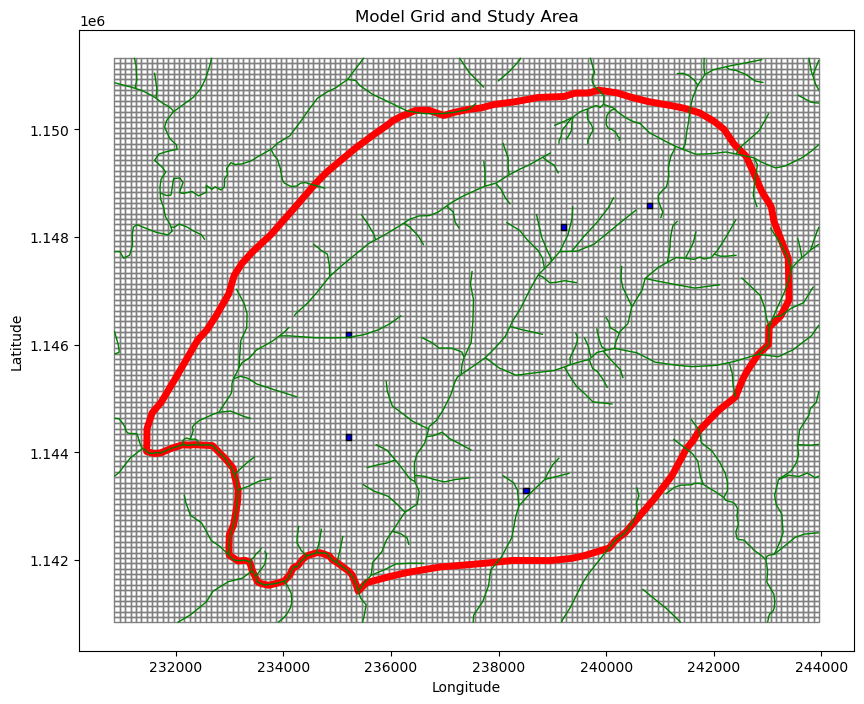

In [46]:
# Plot the grid and the study area then plot well locations
cwd = os.getcwd()
griddf = gpd.read_file(os.path.join(cwd, "..", "gisfiles", "processed_gis", "topo_grid.shp"))
study_area = gpd.read_file(os.path.join(cwd, "..", "data", "Rawdata", "limite_nouveau", "zone_etude_vf.shp"))
fig, ax = plt.subplots(figsize=(10, 10))
griddf.plot(facecolor='none', edgecolor='gray', ax=ax)
study_area.plot(facecolor='none', edgecolor='red', linewidth=5, ax=ax)
# Plot the stream network
stream_network = gpd.read_file(os.path.join(cwd, "..", "gisfiles", "processed_gis", "HYD_Cours_eau_clip.shp"))
# Project the stream network to match the model grid's CRS if they differ
if stream_network.crs != griddf.crs:
    stream_network = stream_network.to_crs(griddf.crs)  
stream_network.plot(ax=ax, color='green', linewidth=1)
wellsmfrc = [25077, 54044, 78100, 35044, 74084]
for mfrowcol in wellsmfrc:
    wells = griddf[griddf['mfrowcol'] == mfrowcol]
    wells.plot(facecolor='blue', edgecolor='black', ax=ax)
plt.title("Model Grid and Study Area")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [49]:
cwd = os.getcwd()
# Set up directories and paths

data_dir = os.path.join(cwd, '..', 'data')
processed_gis_dir = os.path.join(cwd, '..', 'gisfiles', 'processed_gis')
modflow_dir = os.path.join(cwd, "..", "model")

# Create modflow directory if it doesn't exist
os.makedirs(modflow_dir, exist_ok=True)

# Load topography grid
topo_asc = os.path.join(processed_gis_dir, 'top.asc')
topo_grid = np.loadtxt(topo_asc, skiprows=6)

# Get grid dimensions
nrows, ncols = topo_grid.shape
print(f"Grid dimensions: {nrows} rows x {ncols} columns")

# Read the ASCII grid header to get cell size and bounds
with open(topo_asc, 'r') as f:
    lines = [f.readline() for _ in range(6)]
    ncols_h = int(lines[0].split()[1])
    nrows_h = int(lines[1].split()[1])
    xllcorner = float(lines[2].split()[1])
    yllcorner = float(lines[3].split()[1])
    cellsize = float(lines[4].split()[1])

delr = np.full(ncols, cellsize)  # Column widths
delc = np.full(nrows, cellsize)  # Row widths

# Create 3-layer model
nlay = 3
nper = 1  # Number of stress periods

# Define layer bottom elevations (roughly 100m intervals below surface)
top_elev = topo_grid  # Top of model = topography
bot1 = top_elev - 100   # Bottom of layer 1
bot2 = bot1 - 30      # Bottom of layer 2
bot3 = bot2 - 100      # Bottom of layer 3

botm = np.array([bot1, bot2, bot3])

# Load idomain file (ibound.dat) and apply to all 3 layers
ibound_2d = np.loadtxt(os.path.join(processed_gis_dir, 'ibound.dat'), dtype=int)
idomain = np.zeros((nlay, nrows, ncols), dtype=int)
for k in range(nlay):
    idomain[k] = ibound_2d

# Create MODFLOW-6 simulation
modelname = 'minet01'
mf6_exe = os.path.join(modflow_dir, 'mf6.exe')
sim = flopy.mf6.MFSimulation(sim_name=modelname, sim_ws=modflow_dir, exe_name=mf6_exe)

# Create time discretization
tdis = flopy.mf6.ModflowTdis(sim, nper=nper, perioddata=[(1.0, 1, 1.0)], time_units='days')

# Create groundwater flow model
gwf = flopy.mf6.ModflowGwf(sim, modelname=modelname, save_flows=True)

# Create discretization package
dis = flopy.mf6.ModflowGwfdis(
    gwf,
    nlay=nlay,
    nrow=nrows,
    ncol=ncols,
    delr=delr,
    delc=delc,
    top=top_elev,
    botm=botm,
    idomain=idomain,
)

start_head = np.full((nlay, nrows, ncols), 1.0)
start_head[0] = topo_grid  # Start heads in layer 1 = topography
start_head[1] = bot1
  # Start heads in layer 2 = bottom of layer 1
start_head[2] = bot2
  # Start heads in layer 3 = bottom of layer 2
# Create initial conditions package
ic = flopy.mf6.ModflowGwfic(gwf, strt=start_head)

# Load conductivity data (example: uniform or from file)
# Adjust based on available ASCII grids for conductivity
hk = np.full((nlay, nrows, ncols), 1.0)  # Horizontal conductivity (m/day)
vk = np.full((nlay, nrows, ncols), 0.1)  # Vertical conductivity (m/day)

# Layered properties example
hk[0] = np.loadtxt(os.path.join(processed_gis_dir, 'hk1.dat'))  # Layer 1 - higher K from file
hk[1] = np.loadtxt(os.path.join(processed_gis_dir, 'hk2.dat'))  # Layer 2 - lower K from file
hk[2] = np.loadtxt(os.path.join(processed_gis_dir, 'hk3.dat'))  # Layer 3 - medium K from file

# Create node property flow package
npf = flopy.mf6.ModflowGwfnpf(gwf, k=hk, k33=vk, save_flows=True)

# Load river locations from grid
riv_grid = np.loadtxt(os.path.join(processed_gis_dir, 'riv_grid.dat'))

# mask out the inactive cells using the ibound array
riv_grid[ibound_2d == 0] = 0  # Set river grid to 0 where ibound is 0 (inactive)

# Create river package based on riv field
riv_cells = []
if os.path.exists(os.path.join(processed_gis_dir, 'riv_grid.dat')):
    for i in range(nrows):
        for j in range(ncols):
            if riv_grid[i, j] == 1:
                # River in layer 1 (top layer)
                riv_elev = top_elev[i, j] - 5  # Riverbed 5m below surface
                riv_cond = 10.0  # Conductance
                riv_cells.append([(0, i, j), riv_elev, riv_cond, riv_elev])

if riv_cells:
    riv = flopy.mf6.ModflowGwfriv(gwf, stress_period_data={0: riv_cells})
    print(f"Created river package with {len(riv_cells)} cells")

# Create well package with specified fluxes (negative for extraction) 25077, 54044, 78100, 35044, 74084
well_entries = [
    (1, 25, 77, -19),
    (3, 54, 44, -13),
    (3, 78, 100, -15),
    (3, 35, 44, -13),
    (1, 74, 84, -7),
]

stress_period_data = [
    ((layer - 1, row - 1, col - 1), flux)
    for layer, row, col, flux in well_entries
]

wel = flopy.mf6.ModflowGwfwel(
    gwf,
    stress_period_data={0: stress_period_data},
)

#create a recharge package that applies recharge to the top layer at a rate of 0.001 m/day
recharge_rate = 0.001  # m/day
# rch = flopy.mf6.ModflowGwfrch(gwf, recharge=recharge_rate)
rch = flopy.mf6.ModflowGwfrcha(
    gwf,
    pname='rch',
    recharge=recharge_rate,
    filename='minet01.rcha'
)

# Create output control package
oc = flopy.mf6.ModflowGwfoc(
    gwf,
    head_filerecord=f"{modelname}.hds",
    budget_filerecord=f"{modelname}.cbc",
    saverecord=[('HEAD', 'ALL'), ('BUDGET', 'ALL')],
)


# Create IMS solver
ims = flopy.mf6.ModflowIms(sim, complexity='SIMPLE')

# Write model files
sim.write_simulation()
print(f"\nMODFLOW-6 model created in: {modflow_dir}")
print(f"Model name: {modelname}")

Grid dimensions: 105 rows x 131 columns
Created river package with 1166 cells
writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model minet01...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package npf...
    writing package riv_0...
INFORMATION: maxbound in ('', 'riv', 'dimensions') changed to 1166 based on size of stress_period_data
    writing package wel_0...
INFORMATION: maxbound in ('', 'wel', 'dimensions') changed to 5 based on size of stress_period_data
    writing package rch...
    writing package oc...

MODFLOW-6 model created in: c:\Users\mouss\modeling\gitrepo\mine-t01\scripts\..\model
Model name: minet01


In [50]:
# run the simulation using the command line interface
success, buff = sim.run_simulation()
if success:
    print("\nMODFLOW-6 simulation completed successfully.")
else:
    print("\nMODFLOW-6 simulation failed. Check the output for details.")   

FloPy is using the following executable to run the model: mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.7.0 02/05/2026

   MODFLOW 6 compiled Feb 05 2026 22:36:44 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications running on Intel(R) 64, Version 2021.6.0
                             Build 20220226_000000

This software has been approved for release by the U.S. Geological 
Survey (USGS). Although the software has been subjected to rigorous 
review, the USGS reserves the right to update the software as needed 
pursuant to further analysis and review. No warranty, expressed or 
implied, is made by the USGS or the U.S. Government as to the 
functionality of the software and related material nor shall the 
fact of release constitute any such warranty. Furthermore, the 
software is released on condition that neither the USGS nor the U.S. 
Government shall be held l

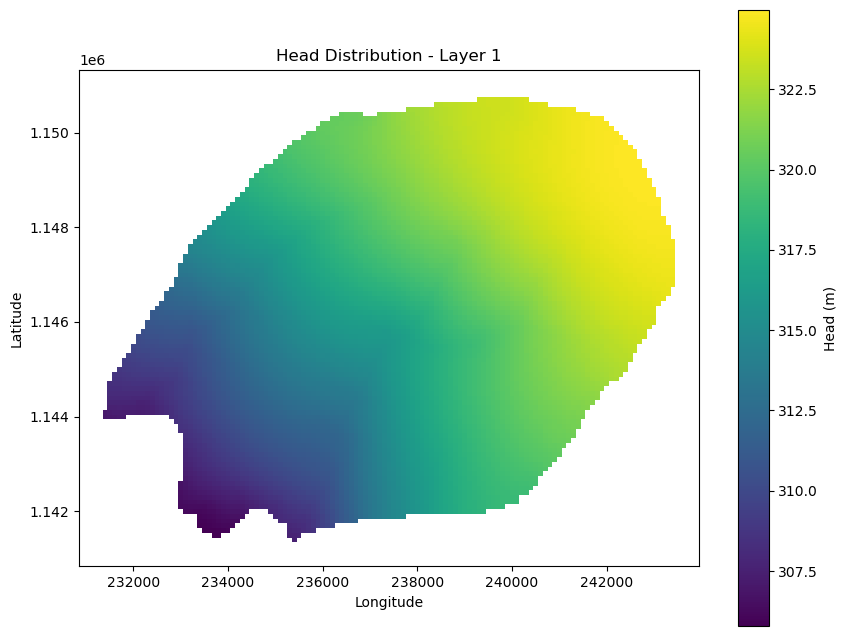

In [55]:
# Process results (example: plot head distribution)
# Always flip the head array to match the grid orientation for plotting, and mask out inactive cells
hds = flopy.utils.HeadFile(os.path.join(modflow_dir, f"{modelname}.hds"))
head = hds.get_data(totim=1.0)  # Get head data
# head = np.flipud(head)  # Flip the head array for correct orientation
ibound_3d = np.zeros((nlay, nrows, ncols), dtype=int)
for k in range(nlay):
    ibound_3d[k] = ibound_2d
head = np.ma.masked_where(ibound_3d == 0, head)  # Mask out inactive cells
#plot head distribution for layer 1
plt.figure(figsize=(10, 8))
plt.imshow(np.flipud(head[0]), extent=(xllcorner, xllcorner + ncols * cellsize, yllcorner, yllcorner + nrows * cellsize), origin='lower')
plt.colorbar(label='Head (m)')
plt.title("Head Distribution - Layer 1")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

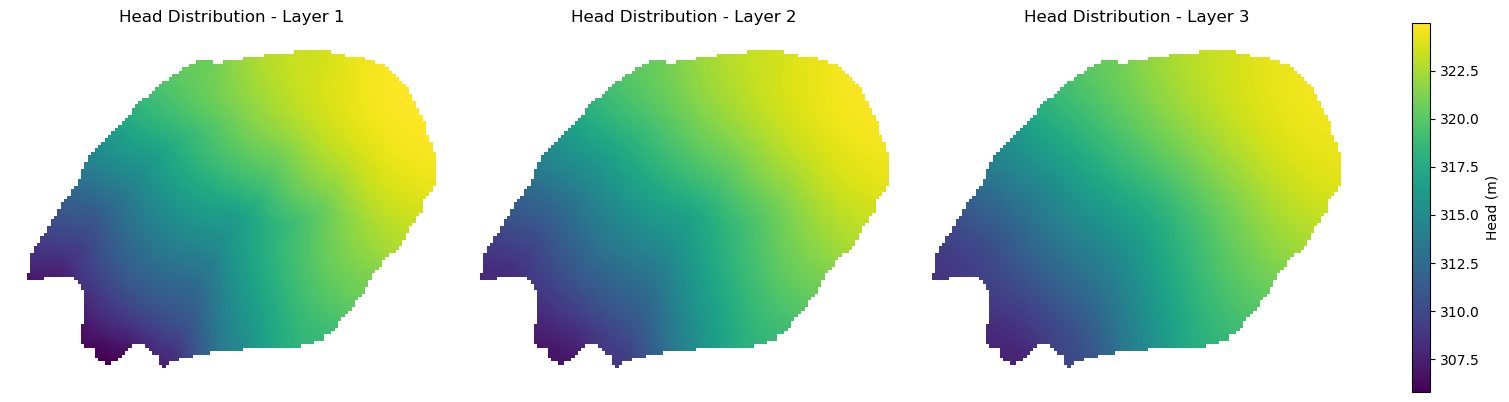

In [64]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
arr1 = head[0]
arr2 = head[1]
arr3 = head[2]

vmin = min(arr.min() for arr in (arr1, arr2, arr3))
vmax = max(arr.max() for arr in (arr1, arr2, arr3))

im = axs[0].imshow(arr1, cmap='viridis', vmin=vmin, vmax=vmax)
axs[0].set_title('Head Distribution - Layer 1')
axs[0].axis('off')

axs[1].imshow(arr2, cmap='viridis', vmin=vmin, vmax=vmax)
axs[1].set_title('Head Distribution - Layer 2')
axs[1].axis('off')

axs[2].imshow(arr3, cmap='viridis', vmin=vmin, vmax=vmax)
axs[2].set_title('Head Distribution - Layer 3')
axs[2].axis('off')

fig.colorbar(im, ax=axs, orientation='vertical', fraction=0.046, pad=0.04, shrink=0.75, label='Head (m)')
plt.show()